# SMC^2 Plotting

This notebook contains code for plotting the results of the SMC^2 algorithm. The first part deals with plotting the results of synthetic data, while the second part focuses on plotting the results of real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

import os
import sys
import ast

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)


d:\School\Fakulteta\2. stopnja\2. letnik\Master


In [20]:
def weighted_quantile(values, quantiles, sample_weight):
    """
    Compute weighted quantiles for 1D samples.

    Parameters
    ----------
    values : ndarray, shape (N,)
    quantiles : array-like in [0, 1]
    sample_weight : ndarray, shape (N,)

    Returns
    -------
    ndarray
        Quantile values.
    """

    values = np.asarray(values)
    quantiles = np.asarray(quantiles)
    sample_weight = np.asarray(sample_weight)

    sorter = np.argsort(values)

    values = values[sorter]
    weights = sample_weight[sorter]

    cdf = np.cumsum(weights)
    cdf /= cdf[-1]

    return np.interp(quantiles, cdf, values)

def weighted_credible_interval(values, weights, alpha=0.05):
    """
    Compute weighted credible intervals componentwise.

    Parameters
    ----------
    values : ndarray
        Shape (N, ...)
        where N = number of particles.

    weights : ndarray
        Shape (N,)

    alpha : float
        Credible level. alpha=0.05 -> 95% CI.

    Returns
    -------
    lower : ndarray
    upper : ndarray

    Both have shape values.shape[1:].
    """

    values = np.asarray(values)

    # -----------------------------------------
    # scalar parameter
    # -----------------------------------------
    if values.ndim == 1:
        q = weighted_quantile(
            values,
            [alpha / 2, 1 - alpha / 2],
            weights
        )
        return q[0], q[1]

    # -----------------------------------------
    # flatten parameter dimensions
    # -----------------------------------------
    original_shape = values.shape[1:]

    flat = values.reshape(values.shape[0], -1)

    lower = np.empty(flat.shape[1])
    upper = np.empty(flat.shape[1])

    for j in range(flat.shape[1]):

        q = weighted_quantile(
            flat[:, j],
            [alpha / 2, 1 - alpha / 2],
            weights
        )

        lower[j] = q[0]
        upper[j] = q[1]

    lower = lower.reshape(original_shape)
    upper = upper.reshape(original_shape)

    return lower, upper

def normalize_logweights(logw):
    """
    Stable normalization of log weights.
    """
    m = np.max(logw)
    w = np.exp(logw - m)
    return w / np.sum(w)

def generate_names(n_params):
    """
    Generate dynamically parameter names based on the number of parameters. 
    First 1 is "mu1", next K-1 are "delta_i", next one is "phi", next one is "sigma" and then K*K flatten parameters P_ij.
    In total there is 1 + (K-1) + 1 + 1 + K*K = K*K + K + 2 parameters.
    """
    K = int(-1+np.sqrt(n_params+1))

    names = []
    names.append("mu1")
    for i in range(K-1):
        names.append(f"delta_{i}")
    names.append("phi")
    names.append("sigma")
    for i in range(K):
        for j in range(K):
            names.append(f"P_{i}_{j}")

    return names

## Synthetic Data

We plot resutls for multiple datasets, each with different regime settings. We have 6 synthetic datasets, each with 2 regimes. First three datasets have similar parameters as follows:
- $\mu_1 = -5.0$
- $\mu_2 = -2.0$
- $\sigma = 0.1$
- $P = \begin{bmatrix} 0.99 & 0.01 \\ 0.015 & 0.985 \end{bmatrix}$

with different $\phi$ values:
- Dataset 1: $\phi = 0.9$
- Dataset 2: $\phi = 0.7$
- Dataset 3: $\phi = 0.5$

The next three datasets have again similar parameters as follows:
- $\mu_1 = -1.0$
- $\mu_2 = 1.0$
- $\sigma = 0.1$
- $P = \begin{bmatrix} 0.99 & 0.01 \\ 0.05 & 0.95 \end{bmatrix}$

with different $\phi$ values:
- Dataset 4: $\phi = 0.9$
- Dataset 5: $\phi = 0.7$
- Dataset 6: $\phi = 0.5$




In [57]:
# Dataset name setting. Can use "dataset_1", "dataset_2", "dataset_3", "dataset_4", "dataset_5" or "dataset_6"
name = "dataset_6"

In [58]:
experiment_path = os.path.join(parent_dir, "experiments", "mssv_smc2_synth")
print(experiment_path)

d:\School\Fakulteta\2. stopnja\2. letnik\Master\experiments\mssv_smc2_synth


In [59]:
output_dir = os.path.join(experiment_path, name, "output")
results_dir = os.path.join(experiment_path, name, "results")

data_dir = os.path.join(parent_dir, "data", "synthetic")

In [60]:
# Load true data and parameters
from src.models.mssv import MSSVParams

data = pd.read_csv(data_dir + "/" + name + ".csv")
y = data["y"].values
h_true = data["h_true"].values
s_true = data["s_true"].values.astype(int)

params_df = pd.read_csv(data_dir + "/" + name + "_params.csv")
P_rows = params_df["P"].apply(ast.literal_eval).tolist()
P = np.array(P_rows)
true_theta = MSSVParams.from_mu(
    mu=params_df["mu"].values,
    phi=params_df["phi"].iloc[0],
    sigma_eta=params_df["sigma_eta"].iloc[0],
    P=P
)
true_theta = true_theta.to_vector()

First we plot graphs of how the distribution (represented just with mean and $95\%$ CI) of model parameters $\mu_1, \delta_0, \phi, \sigma$ and $P$ evolve over time. As we have synthetic data we also plot the horizonal line that represents the true value of the parameter. The plots are saved in the `results_dir` directory.

Parameter names: ['mu1', 'delta_0', 'phi', 'sigma', 'P_0_0', 'P_0_1', 'P_1_0', 'P_1_1']


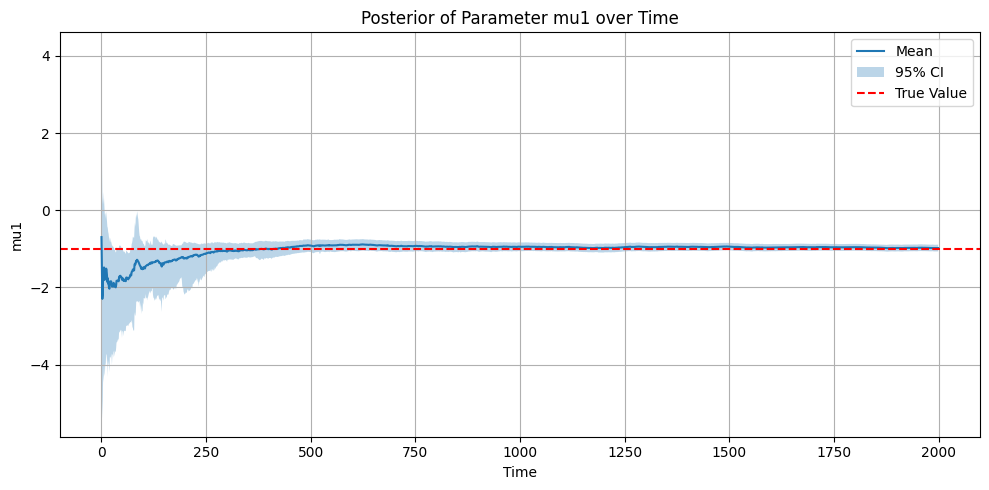

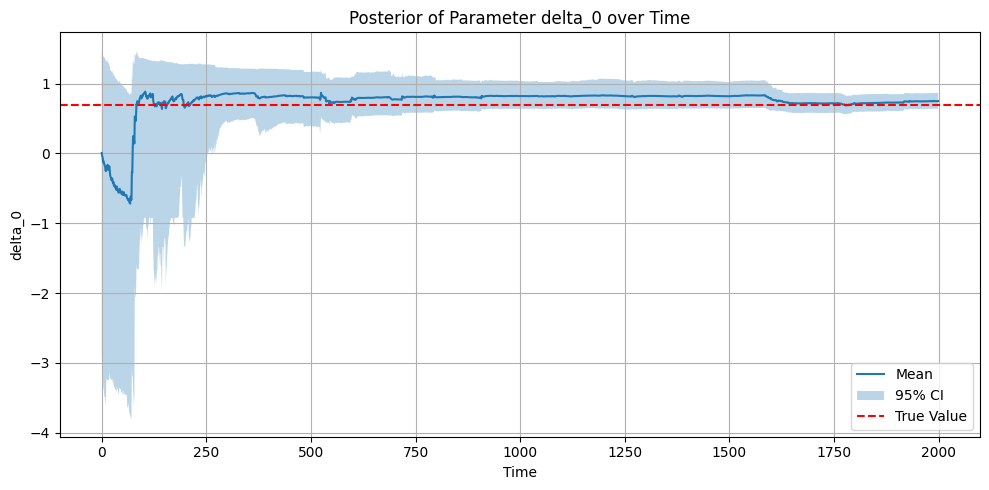

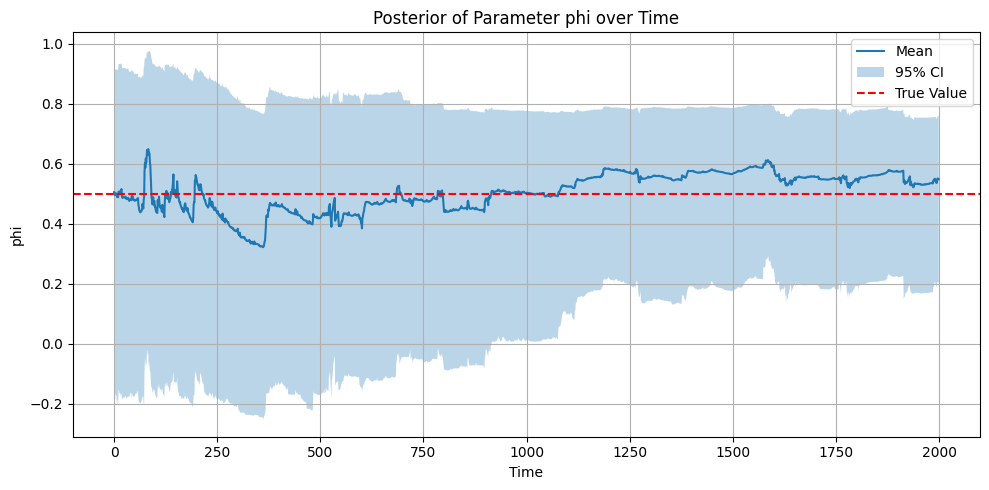

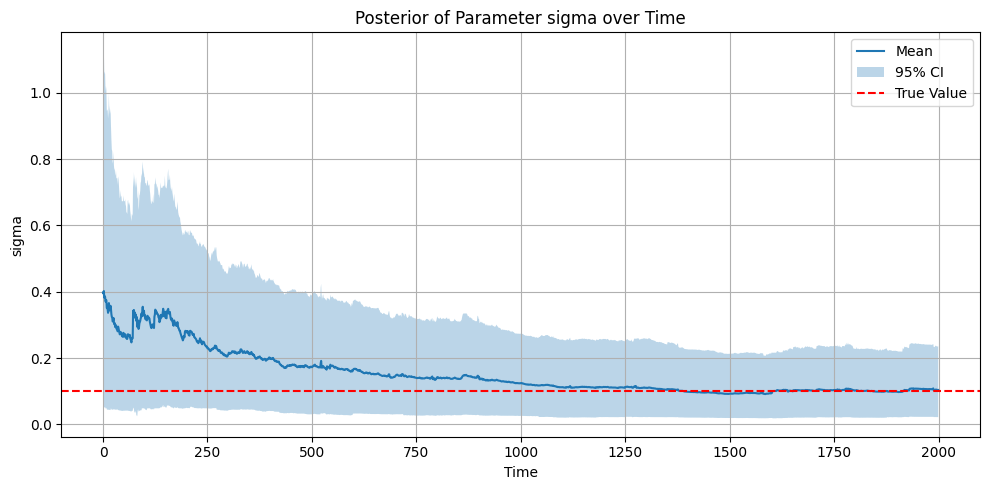

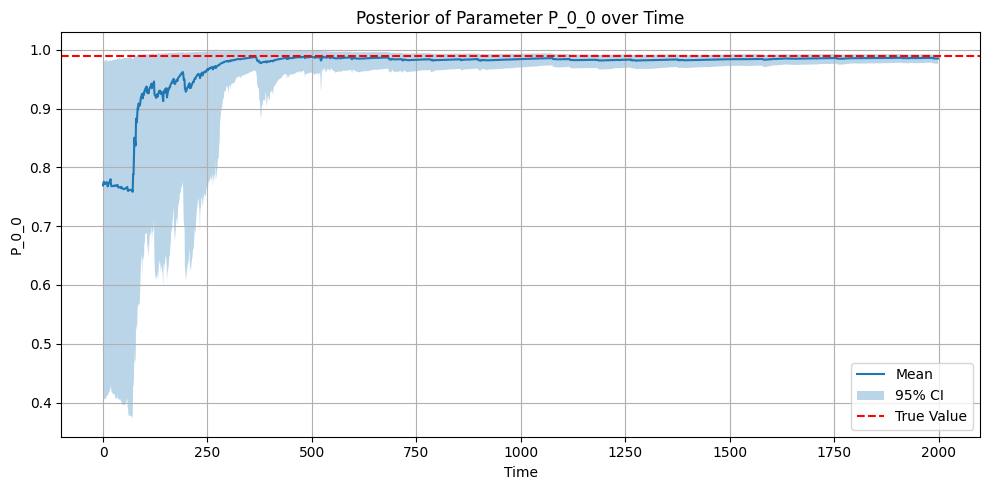

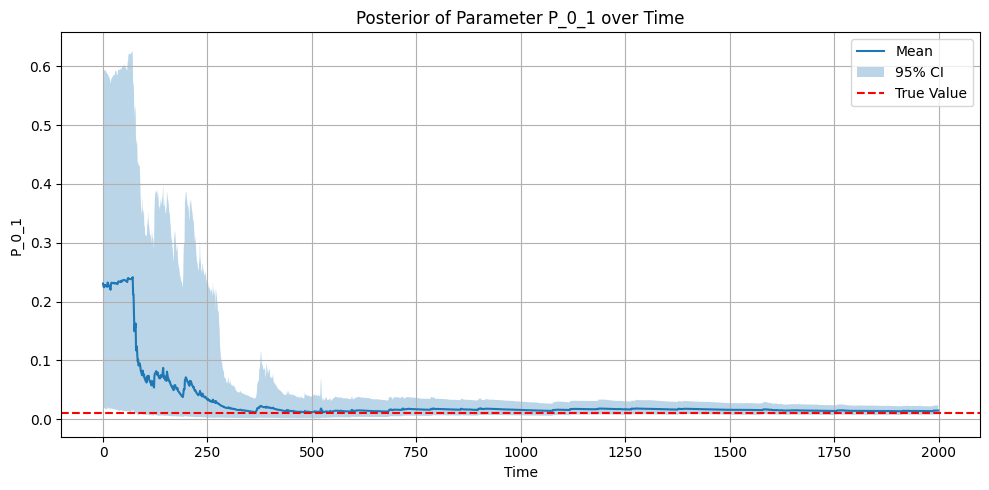

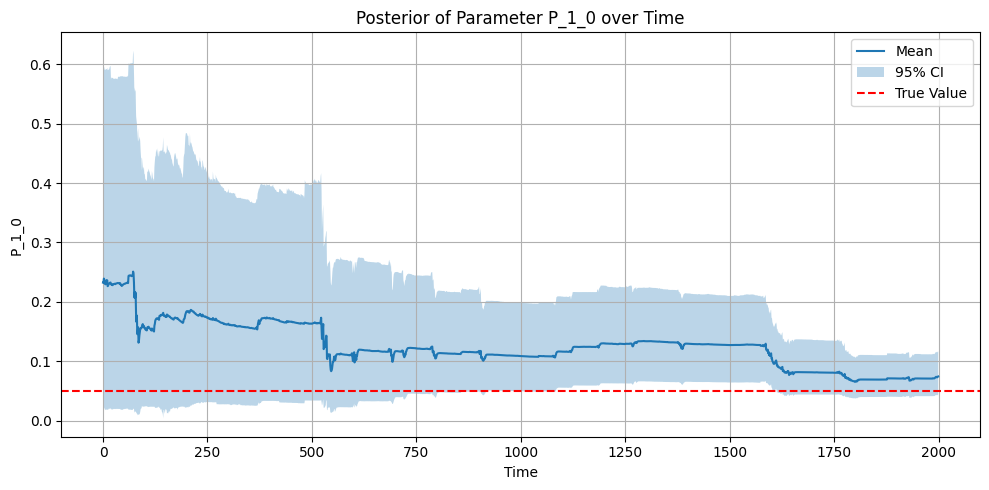

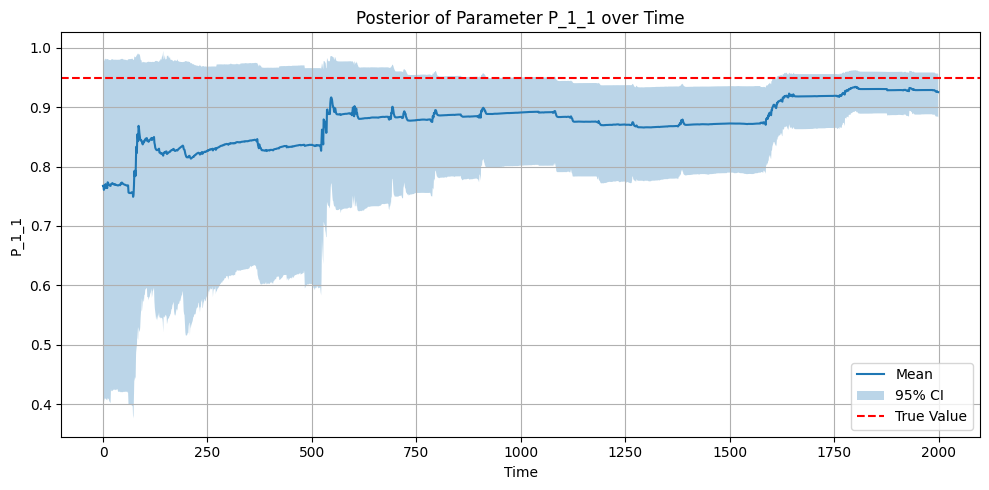

In [61]:
with h5py.File(output_dir + "/theta_history.h5", "r") as h5f:
    theta = h5f["theta"][:]
    logweights = h5f["logweights"][:]

T_plus_1, N_theta, n_params = theta.shape

h_true = h_true[:T_plus_1-1]  # Exclude t=0 since it's the prior
s_true = s_true[:T_plus_1-1]  # Exclude t=0 since it's the prior

parameter_names = generate_names(n_params)
print("Parameter names:", parameter_names)

# Storage
means = np.zeros((T_plus_1, n_params))
lower = np.zeros((T_plus_1, n_params))
upper = np.zeros((T_plus_1, n_params))

# ---------------------------------------------------
# Compute weighted summaries
# ---------------------------------------------------
for t in range(T_plus_1):
    w = normalize_logweights(logweights[t])
    for j in range(n_params):
        x = theta[t, :, j]
        # weighted mean
        means[t, j] = np.sum(w * x)
        # weighted CI
        lo, hi = weighted_credible_interval(x, w, alpha=0.05)
        lower[t, j] = lo
        upper[t, j] = hi

# ---------------------------------------------------
# Plot theta parameters with time
# ---------------------------------------------------
time = np.arange(T_plus_1-1)  # Exclude t=0 since it's the prior

for j in range(n_params):
    plt.figure(figsize=(10, 5))
    plt.plot(time,means[1:, j],label="Mean")                                        # Exclude t=0 since it's the prior
    plt.fill_between(time,lower[1:, j],upper[1:, j],alpha=0.3,label="95% CI")       # Exclude t=0 since it's the prior

    plt.axhline(true_theta[j], color="red", linestyle="--", label="True Value")

    plt.xlabel("Time")
    plt.ylabel(f"{parameter_names[j]}")
    plt.title(f"Posterior of Parameter {parameter_names[j]} over Time")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(results_dir + f"/{parameter_names[j]}.png")
    plt.show()

Now let's plot the entire distribution of those parameters for specific time points. 

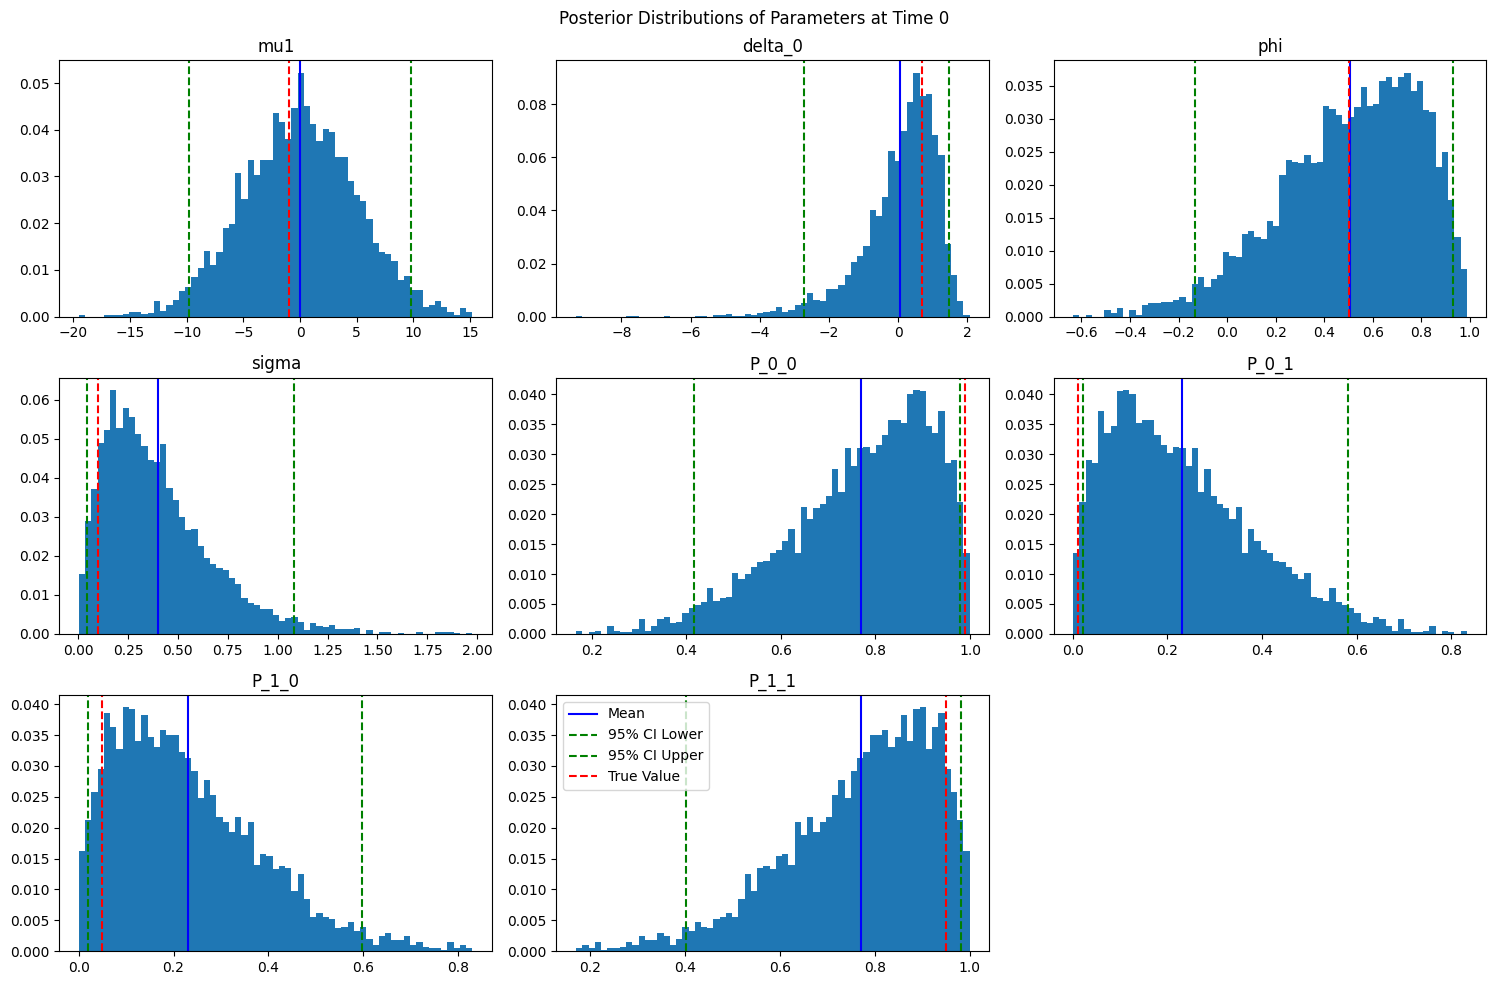

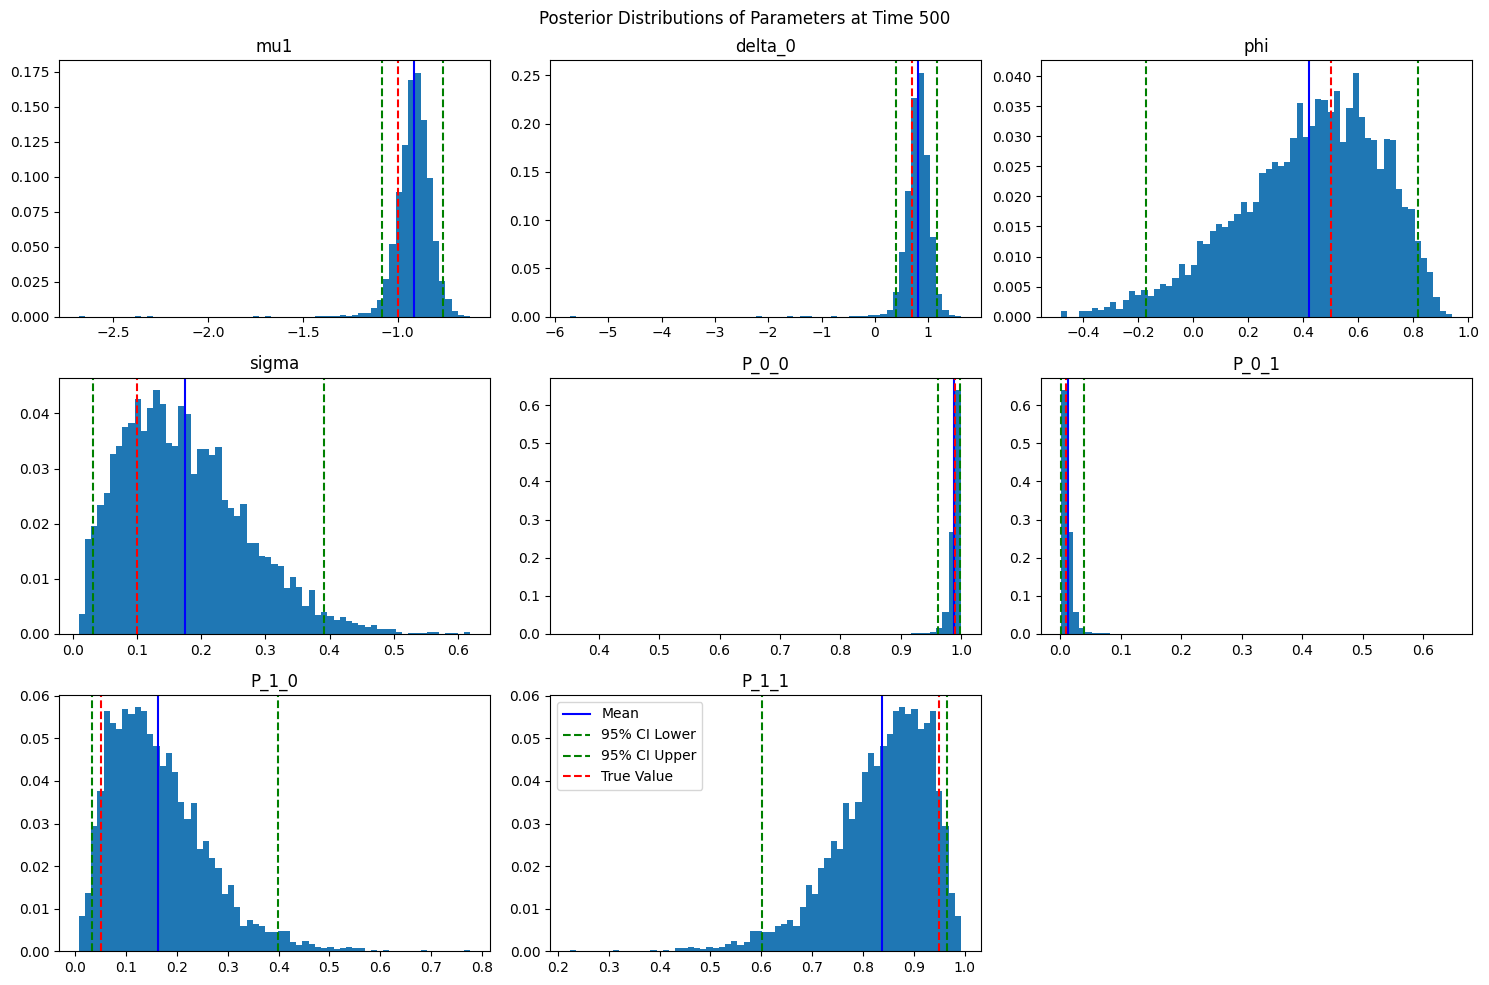

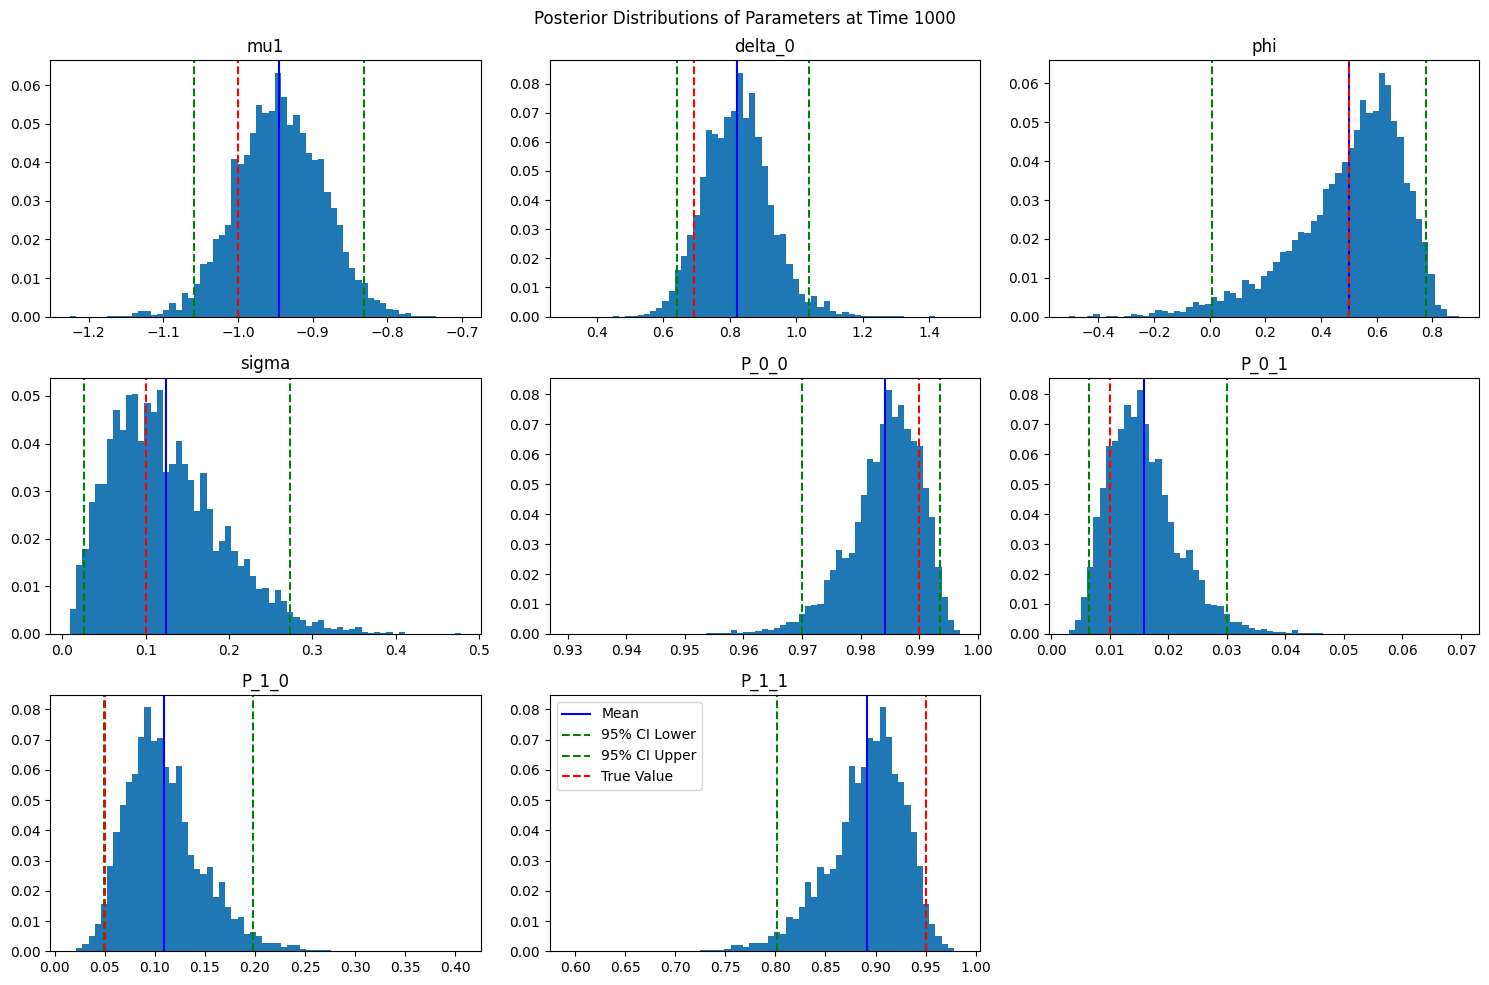

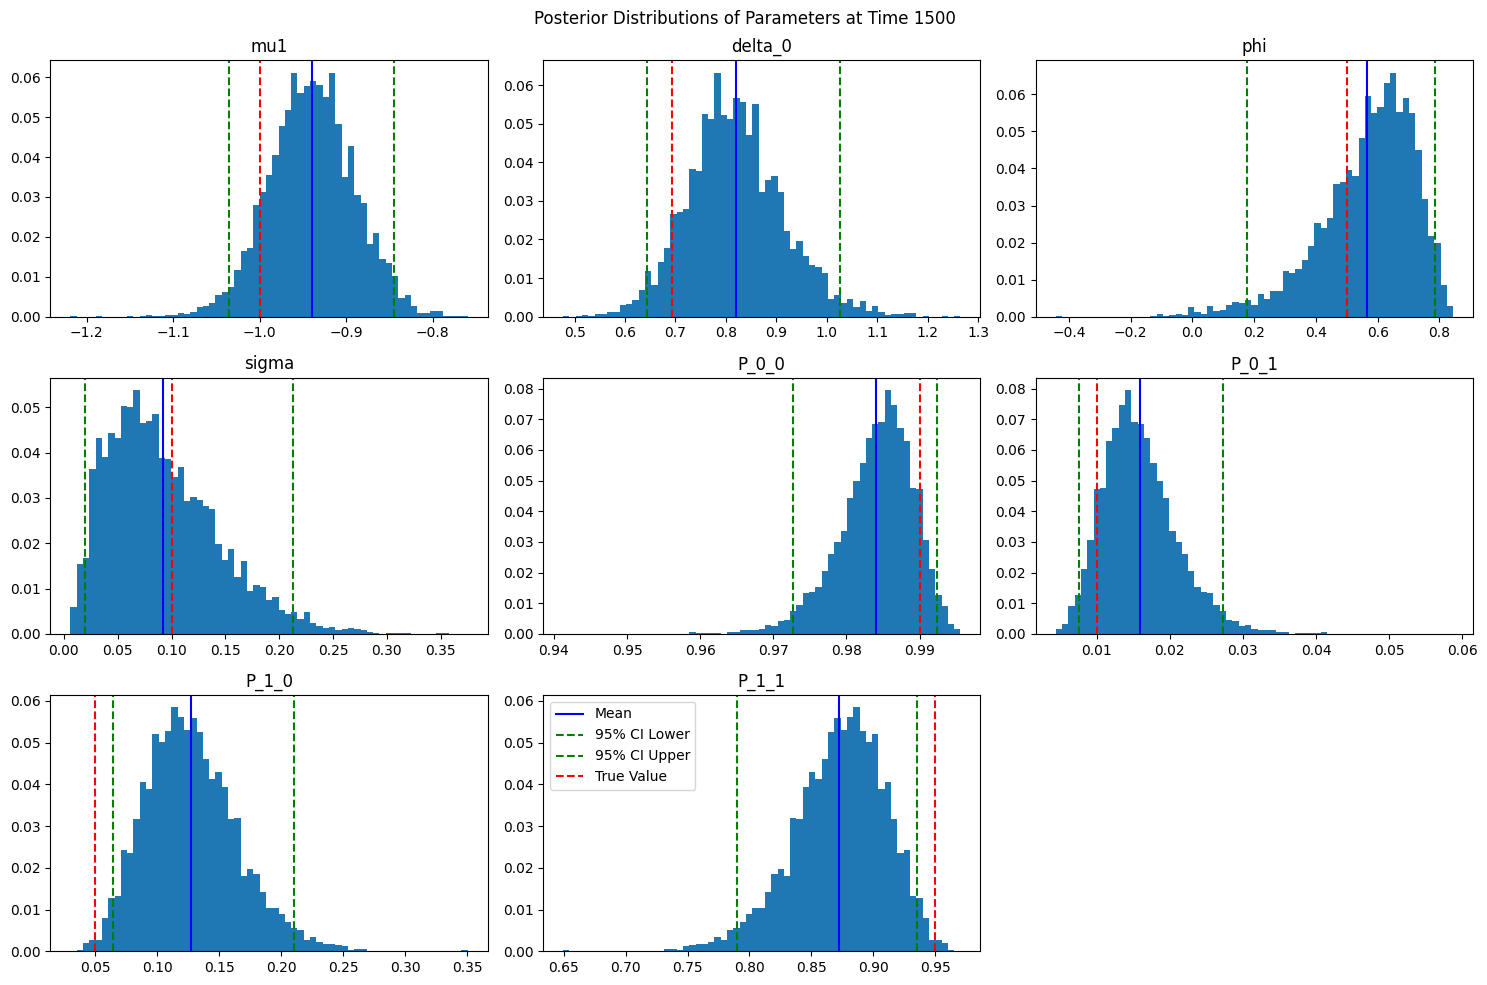

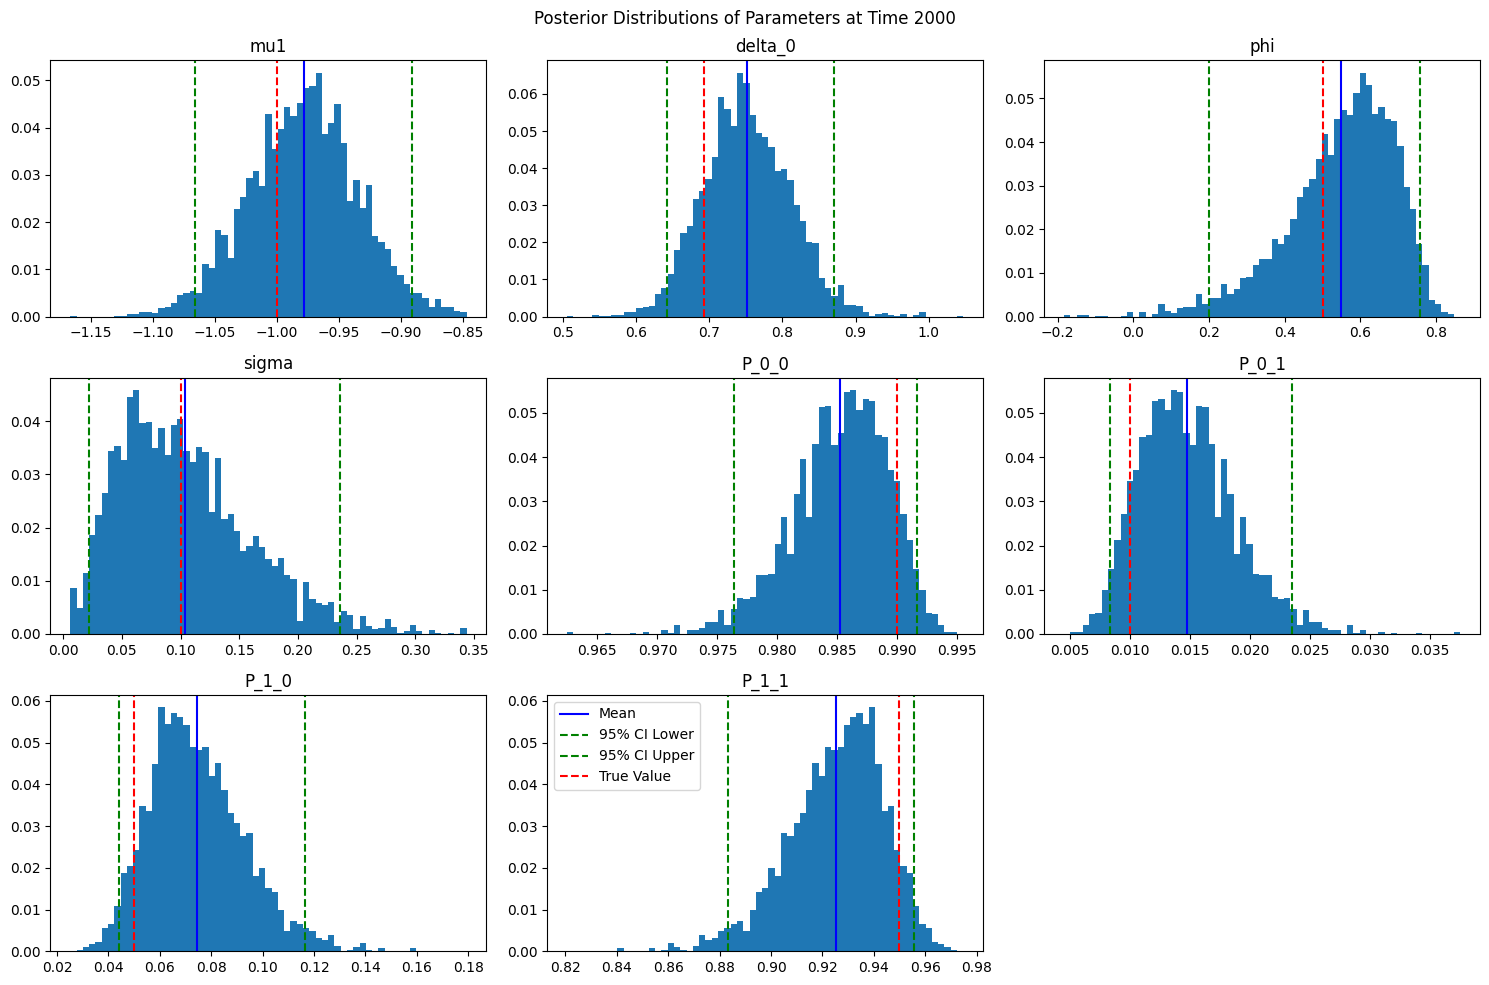

In [62]:
T = [0, 500, 1000, 1500, 2000]

for t in T:
    n_param = len(parameter_names)
    # Make subplots on some n*n grid of plots
    n_cols = int(np.ceil(np.sqrt(n_param)))
    n_rows = int(np.ceil(n_param / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
    for j in range(n_param):
        row = j // n_cols
        col = j % n_cols
        ax = axes[row, col]

        ax.hist(theta[t, :, j], bins=int(np.sqrt(len(theta[t, :, j]))), weights=normalize_logweights(logweights[t]))
        ax.axvline(means[t, j], color="blue", linestyle="-", label="Mean")
        ax.axvline(lower[t, j], color="green", linestyle="--", label="95% CI Lower")
        ax.axvline(upper[t, j], color="green", linestyle="--", label="95% CI Upper")
        ax.axvline(true_theta[j], color="red", linestyle="--", label="True Value")
        ax.set_title(f"{parameter_names[j]}")

    # Remove empty subplots
    for j in range(n_param, n_rows * n_cols):
        row = j // n_cols
        col = j % n_cols
        fig.delaxes(axes[row, col])

    plt.suptitle(f"Posterior Distributions of Parameters at Time {t}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Now we plot the filtering $p(h_t | y_{1:t})$, smoothing $p(h_t | y_{1:T})$ and predictive $p(h_{t+1} | y_{1:t})$ distributions of the log volatility $h_t$ over time. The plots are saved in the `results_dir` directory.

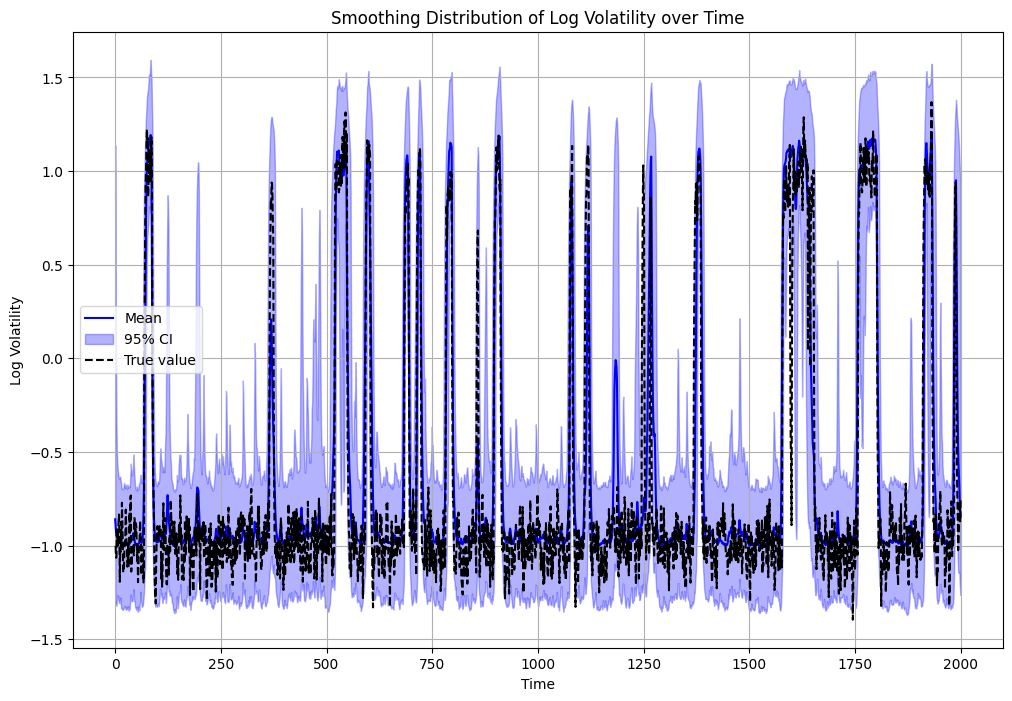

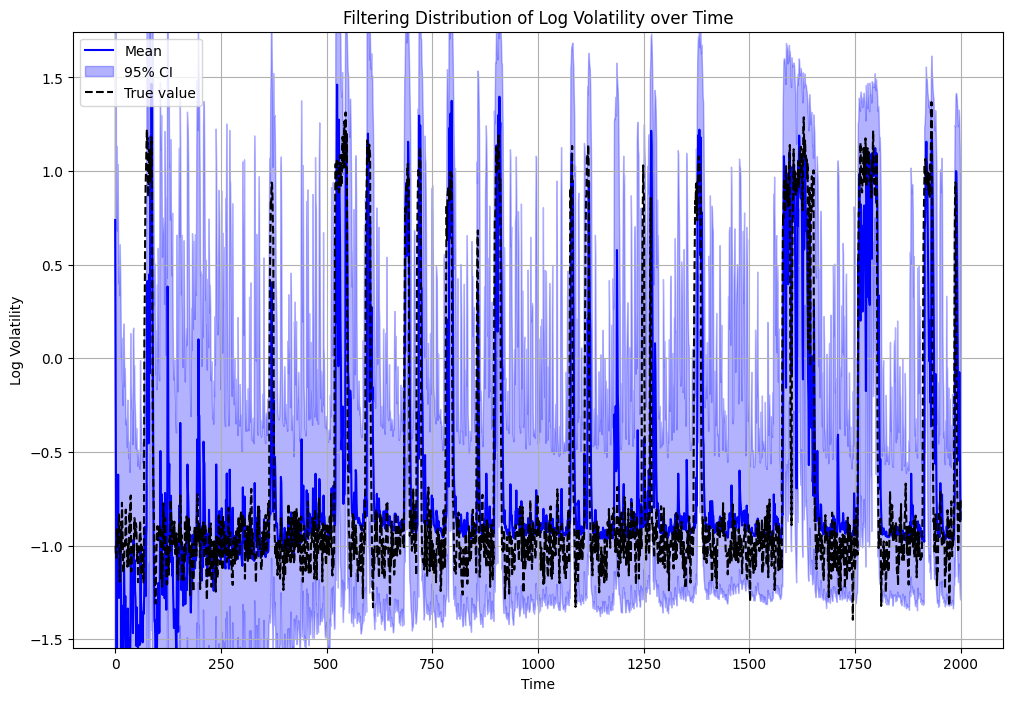

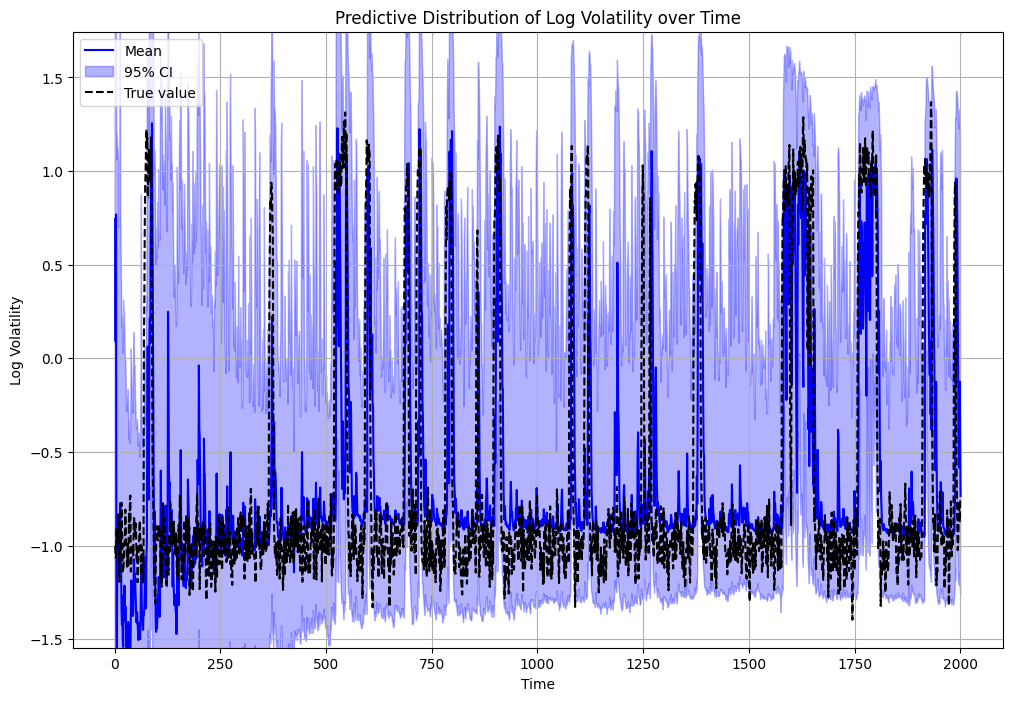

In [63]:
with h5py.File(output_dir + "/state_history.h5", "r") as h5f:
    x_particles = h5f["x_particles"][:]
    trajectories = h5f["trajectories"][:]
    x_particles_pred = h5f["x_particles_pred"][:]

# Plot smoothing distribution (mean and 95% CI) with time
last_theta_weights = logweights[-1]
last_theta_weights = normalize_logweights(last_theta_weights)   # shape (N_theta,)
N_theta, Tp1, save_factor, state_dim = trajectories.shape

trajectories = (
    np.swapaxes(trajectories, 1, 2)      # (N_theta, save_factor, T+1, state_dim)
    .reshape(N_theta * save_factor, Tp1, state_dim)
)

last_traj_weights = np.repeat(last_theta_weights, save_factor)   # shape (N_theta * save_factor,)
last_traj_weights = last_traj_weights / np.sum(last_traj_weights)

h_values = trajectories[:, :, 0]     # shape (N_theta * save_factor, T+1)
means = np.sum(last_traj_weights[:, None] * h_values, axis=0)
lower, higher = weighted_credible_interval(h_values, last_traj_weights, alpha=0.05)

plt.figure(figsize=(12, 8))
plt.plot(means, label="Mean", color='blue')
plt.fill_between(np.arange(len(means)), lower, higher, alpha=0.3, label="95% CI", color='blue')
plt.plot(np.arange(1, len(h_true)+1), h_true, label="True value", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Smoothing Distribution of Log Volatility over Time")
plt.grid(True)
plt.legend()
plt.savefig(results_dir + "/smoothing_h.png")
ax = plt.gca()
ylims = ax.get_ylim()
plt.show()
plt.close()

# Plot filtering distribution (mean and 95% CI) with time
h_values = x_particles[:, :, 0]     # Particles are equally weighted, so we can just take the mean and quantiles without weights
means = np.mean(h_values, axis=1)
lower, higher = np.percentile(h_values, [2.5, 97.5], axis=1)
plt.figure(figsize=(12, 8))
plt.plot(means, label="Mean", color='blue')
plt.fill_between(np.arange(len(means)), lower, higher, alpha=0.3, label="95% CI", color='blue')
plt.plot(np.arange(1, len(h_true)+1), h_true, label="True value", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Filtering Distribution of Log Volatility over Time")
plt.grid(True)
plt.legend()
plt.ylim(ylims)  # Use the same y-limits as the smoothing plot for better comparison
plt.savefig(results_dir + "/filtering_h.png")
plt.show()
plt.close()

# Plot filtering predicative distribution (mean and 95% CI) with time
h_values = x_particles_pred[:, :, 0]     # Particles are equally weighted, so we can just take the mean and quantiles without weights
means = np.mean(h_values, axis=1)
lower, higher = np.percentile(h_values, [2.5, 97.5], axis=1)
plt.figure(figsize=(12, 8))
plt.plot(np.arange(1, len(means)+1), means, label="Mean", color='blue')     # Start at 1, because we predict p(h_{t+1} | y_{1:t})
plt.fill_between(np.arange(1, len(means)+1), lower, higher, alpha=0.3, label="95% CI", color='blue')    # Same here
plt.plot(np.arange(1, len(h_true)+1), h_true, label="True value", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Predictive Distribution of Log Volatility over Time")
plt.grid(True)
plt.ylim(ylims)  # Use the same y-limits as the smoothing plot for better comparison
plt.legend()
plt.savefig(results_dir + "/predictive_h.png")
plt.show()
plt.close()

On these plots it is hard to see any details, so let's zoom in the last $N$ time steps. 

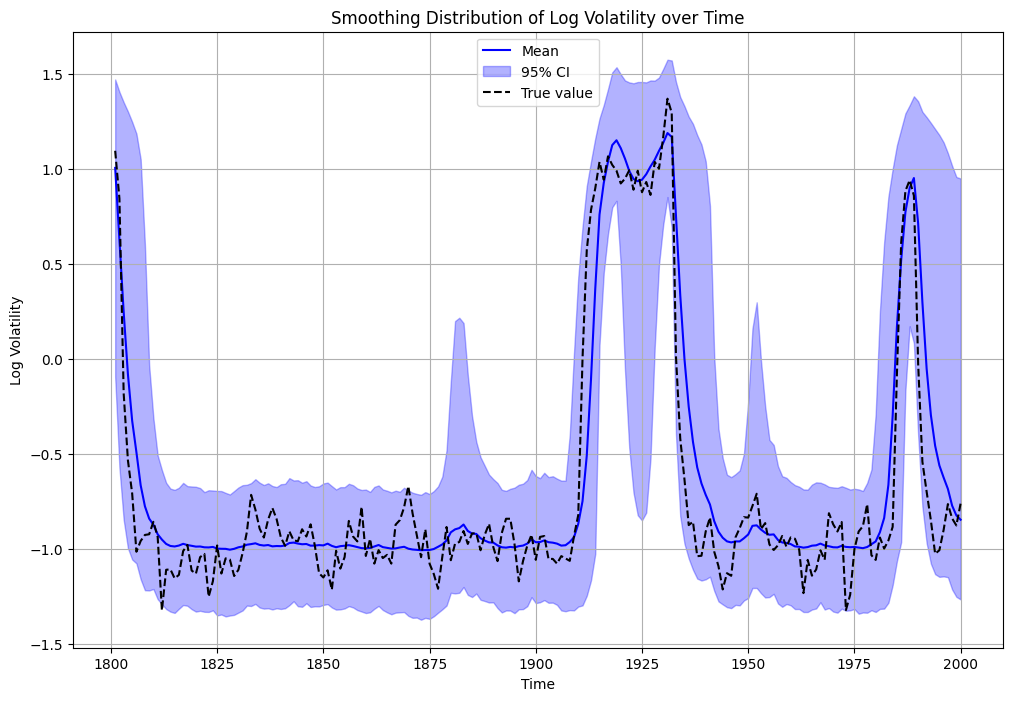

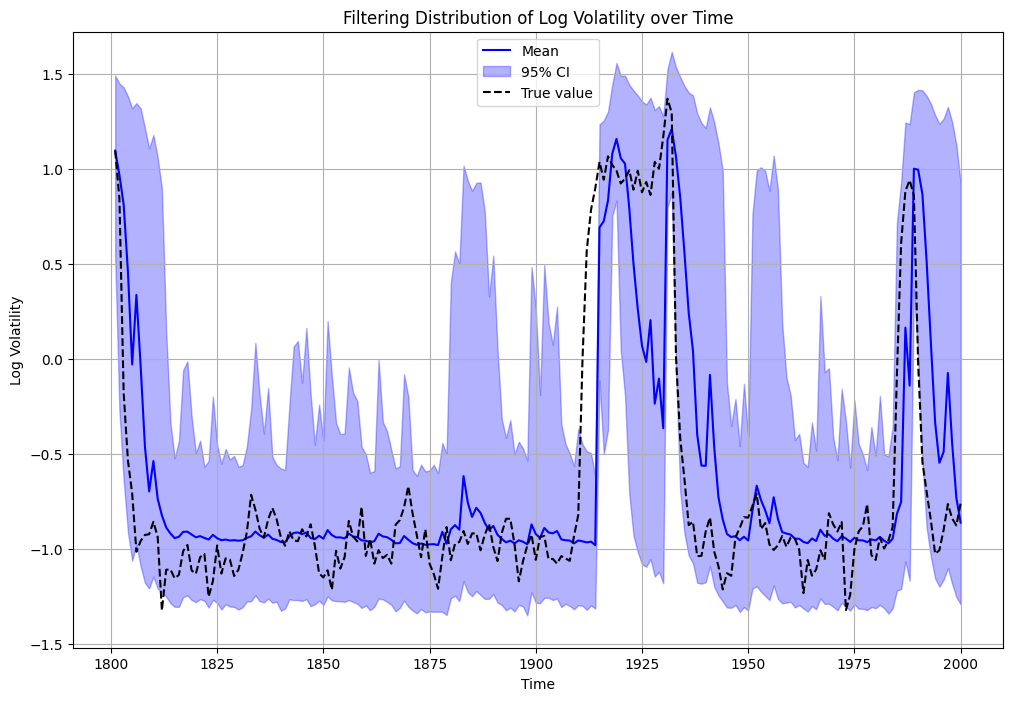

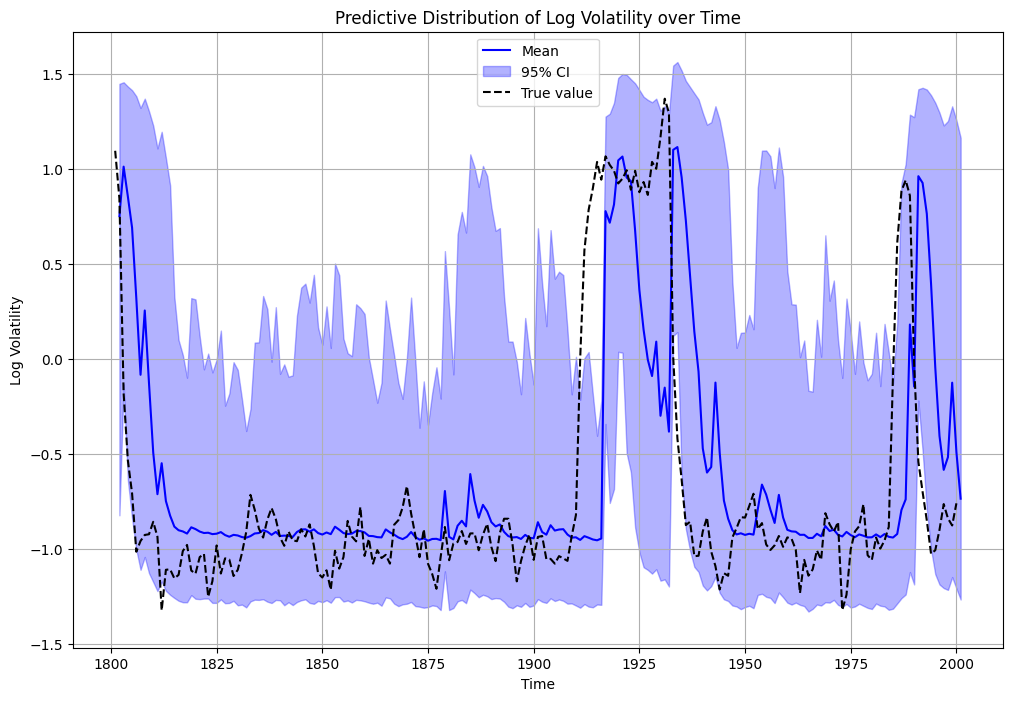

In [64]:
N = 200

x_start = len(means) - N
x_end = len(means)

h_values = trajectories[:, :, 0]     # shape (N_theta * save_factor, T+1)
means = np.sum(last_traj_weights[:, None] * h_values, axis=0)
lower, higher = weighted_credible_interval(h_values, last_traj_weights, alpha=0.05)

plt.figure(figsize=(12, 8))
plt.plot(np.arange(x_start, x_end), means[x_start:x_end], label="Mean", color='blue')
plt.fill_between(np.arange(x_start, x_end), lower[x_start:x_end], higher[x_start:x_end], alpha=0.3, label="95% CI", color='blue')
plt.plot(np.arange(x_start, x_end), h_true[x_start-1:x_end-1], label="True value", color='black', linestyle='--')       # h_true has one less element
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Smoothing Distribution of Log Volatility over Time")
plt.grid(True)
plt.legend()
ax = plt.gca()
ylims = ax.get_ylim()
plt.show()
plt.close()

# Plot filtering distribution (mean and 95% CI) with time
h_values = x_particles[:, :, 0]     # Particles are equally weighted, so we can just take the mean and quantiles without weights
means = np.mean(h_values, axis=1)
lower, higher = np.percentile(h_values, [2.5, 97.5], axis=1)
plt.figure(figsize=(12, 8))
plt.plot(np.arange(x_start, x_end), means[x_start:x_end], label="Mean", color='blue')
plt.fill_between(np.arange(x_start, x_end), lower[x_start:x_end], higher[x_start:x_end], alpha=0.3, label="95% CI", color='blue')
plt.plot(np.arange(x_start, x_end), h_true[x_start-1:x_end-1], label="True value", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Filtering Distribution of Log Volatility over Time")
plt.grid(True)
plt.legend()
plt.ylim(ylims)  # Use the same y-limits as the smoothing plot for better comparison
plt.show()
plt.close()

# Plot filtering predicative distribution (mean and 95% CI) with time
h_values = x_particles_pred[:, :, 0]     # Particles are equally weighted, so we can just take the mean and quantiles without weights
means = np.mean(h_values, axis=1)
lower, higher = np.percentile(h_values, [2.5, 97.5], axis=1)
plt.figure(figsize=(12, 8))
plt.plot(np.arange(x_start+1, x_end+1), means[x_start:x_end], label="Mean", color='blue')     # Start at +1, because we predict p(h_{t+1} | y_{1:t})
plt.fill_between(np.arange(x_start+1, x_end+1), lower[x_start:x_end], higher[x_start:x_end], alpha=0.3, label="95% CI", color='blue')    # Same here
plt.plot(np.arange(x_start, x_end), h_true[x_start-1:x_end-1], label="True value", color='black', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Log Volatility")
plt.title("Predictive Distribution of Log Volatility over Time")
plt.grid(True)
plt.ylim(ylims)  # Use the same y-limits as the smoothing plot for better comparison
plt.legend()
plt.show()
plt.close()

It might be better to plot the error (for each estimated value $h_t$) and the root mean squared error RMSE (for the average up until that point).

We plot both the error and RMSE for the filtering and predictive distributions. Smoothing RMSE do not make sense as it uses entire data $y_{1:T}$, so computing RMSE until time $t$ is actually overfit. Hence, we do not plot neither error or RMSE for smoothing. One could perform smoothing at every time step $t$ using only data $y_{1:t}$, but that would be computationally even more expensive.

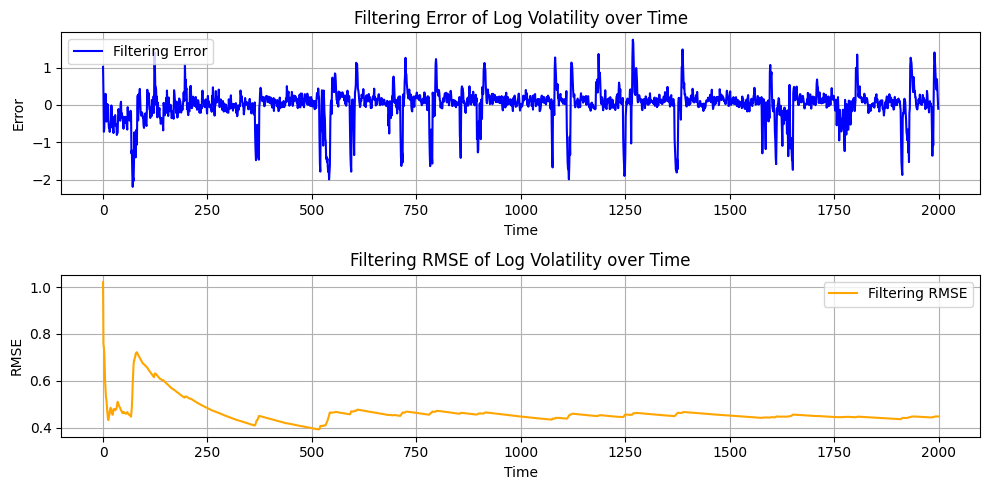

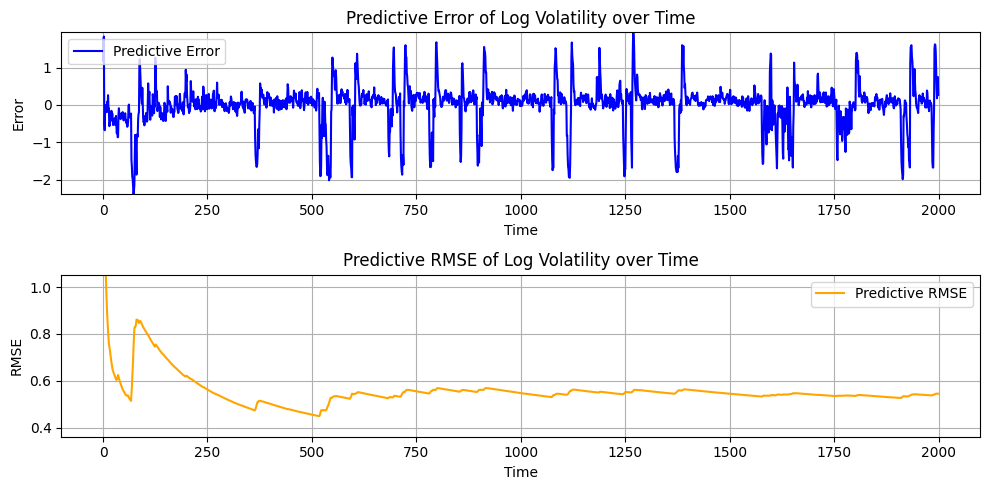

In [65]:
# First filtering
means = np.mean(x_particles[:, :, 0], axis=1)
lower, higher = np.percentile(x_particles[:, :, 0], [2.5, 97.5], axis=1)
label = "Filtering"
diff = means[1:] - h_true       # Exclude t=0 since it's the prior
rmse = np.sqrt(np.cumsum(diff**2) / np.arange(1, len(diff)+1))

# Plot each diff and rmse on two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(diff, label=f"{label} Error", color='blue')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Error")
axes[0].set_title(f"{label} Error of Log Volatility over Time")
axes[0].grid(True)
axes[0].legend()
y0_lims = axes[0].get_ylim()  # Get y-limits of the first plot to use for the second plot

axes[1].plot(rmse, label=f"{label} RMSE", color='orange')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("RMSE")
axes[1].set_title(f"{label} RMSE of Log Volatility over Time")
axes[1].grid(True)
axes[1].legend()
y1_lims = axes[1].get_ylim()  # Get y-limits of the second plot

plt.tight_layout()
plt.show()



# Now predictive
means = np.mean(x_particles_pred[:, :, 0], axis=1)
lower, higher = np.percentile(x_particles_pred[:, :, 0], [2.5, 97.5], axis=1)
label = "Predictive"
diff = means[:len(h_true)] - h_true       # Exclude last point T+1 since we don't have h_true for it
rmse = np.sqrt(np.cumsum(diff**2) / np.arange(1, len(diff)+1))

# Plot each diff and rmse on two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(diff, label=f"{label} Error", color='blue')
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Error")
axes[0].set_title(f"{label} Error of Log Volatility over Time")
axes[0].grid(True)
axes[0].set_ylim(y0_lims)  # Use the same y-limits as the filtering error plot for better comparison
axes[0].legend()

axes[1].plot(rmse, label=f"{label} RMSE", color='orange')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("RMSE")
axes[1].set_title(f"{label} RMSE of Log Volatility over Time")
axes[1].grid(True)
axes[1].set_ylim(y1_lims)  # Use the same y-limits as the filtering RMSE plot for better comparison
axes[1].legend()

plt.tight_layout()
plt.show()

We see that the error and RMSE for filtering is smaller than for predictive, which is kinda expected.